In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

# Agricultural Greenhouse Gas Emissions - Exploratory Data Analysis

In [20]:
# Load the data
df = pd.read_csv('global_greenhouse_gas_emission_from_agriculture (1).csv')
print(f"Dataset shape: {df.shape}")
print(f"\nFirst few rows:")
print(df.head())

Dataset shape: (22216, 17)

First few rows:
  Domain Code            Domain  Area Code (M49)         Area  Element Code  \
0          GT  Emissions totals                4  Afghanistan          7225   
1          GT  Emissions totals                4  Afghanistan          7225   
2          GT  Emissions totals                4  Afghanistan          7225   
3          GT  Emissions totals                4  Afghanistan          7225   
4          GT  Emissions totals                4  Afghanistan          7225   

           Element  Item Code                            Item  Year Code  \
0  Emissions (CH4)       6995  Emissions on agricultural land       1990   
1  Emissions (CH4)       6995  Emissions on agricultural land       1991   
2  Emissions (CH4)       6995  Emissions on agricultural land       1992   
3  Emissions (CH4)       6995  Emissions on agricultural land       1993   
4  Emissions (CH4)       6995  Emissions on agricultural land       1994   

   Year  Source Code    

## 1. Load Data

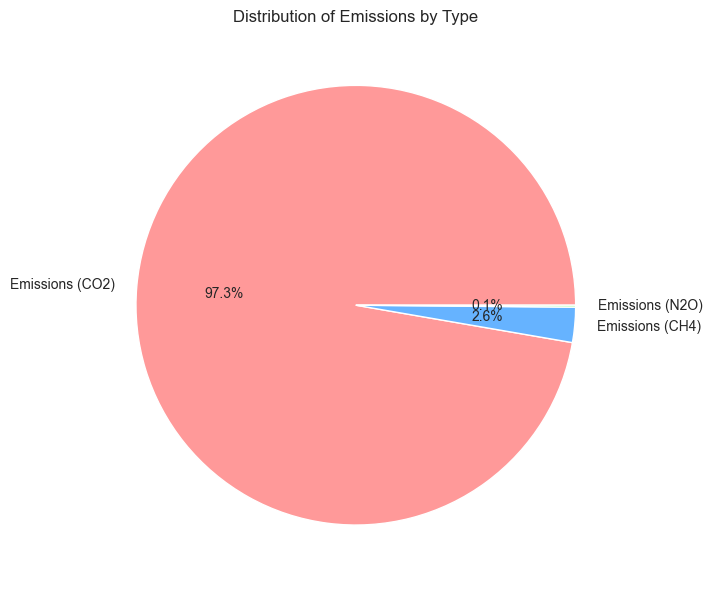

Emissions by Element Type:
Element
Emissions (CO2)    1.834274e+08
Emissions (CH4)    4.869339e+06
Emissions (N2O)    2.649591e+05
Name: Value, dtype: float64


In [19]:
element_emissions = df.groupby('Element')['Value'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
element_emissions.plot(kind='pie', autopct='%1.1f%%', colors=['#ff9999','#66b3ff','#99ff99','#ffcc99'])
plt.ylabel('')
plt.title('Distribution of Emissions by Type')
plt.tight_layout()
plt.show()

print("Emissions by Element Type:")
print(element_emissions)

## 7. Element Distribution

C:\Users\user\AppData\Local\Temp\ipykernel_6160\3824052115.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top, x='Area', y='Value', palette='Set2')


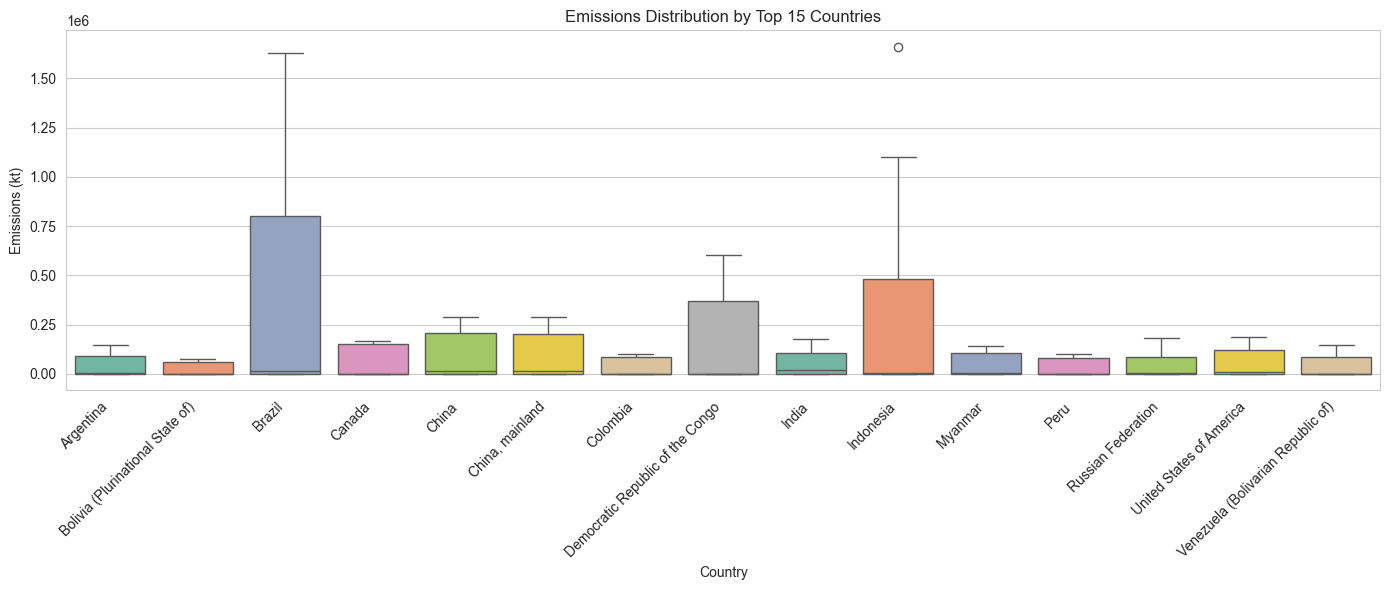

In [23]:
# Top 15 countries box plot
top_15_countries = df.groupby('Area')['Value'].sum().sort_values(ascending=False).head(15).index
df_top = df[df['Area'].isin(top_15_countries)]

plt.figure(figsize=(14, 6))
sns.boxplot(data=df_top, x='Area', y='Value', palette='Set2')
plt.xticks(rotation=45, ha='right')
plt.title('Emissions Distribution by Top 15 Countries')
plt.ylabel('Emissions (kt)')
plt.xlabel('Country')
plt.tight_layout()
plt.show()

## 6 yearly_emissions

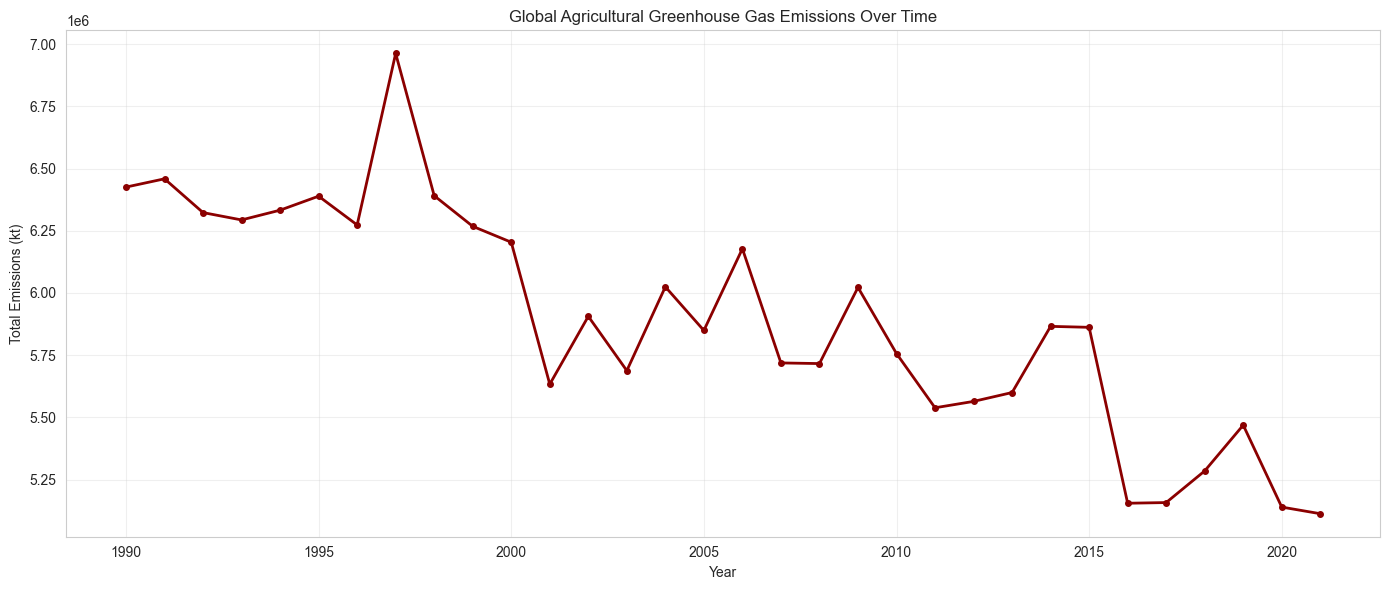


Emissions Statistics Over Time:
Lowest Year: 2021 (5112533.29 kt)
Highest Year: 1997 (6963057.97 kt)


In [14]:
yearly_emissions = df.groupby('Year')['Value'].sum()

plt.figure(figsize=(14, 6))
plt.plot(yearly_emissions.index, yearly_emissions.values, marker='o', linewidth=2, markersize=4, color='darkred')
plt.xlabel('Year')
plt.ylabel('Total Emissions (kt)')
plt.title('Global Agricultural Greenhouse Gas Emissions Over Time')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nEmissions Statistics Over Time:")
print(f"Lowest Year: {yearly_emissions.idxmin()} ({yearly_emissions.min():.2f} kt)")
print(f"Highest Year: {yearly_emissions.idxmax()} ({yearly_emissions.max():.2f} kt)")

## 5. Emissions Trend Over Time

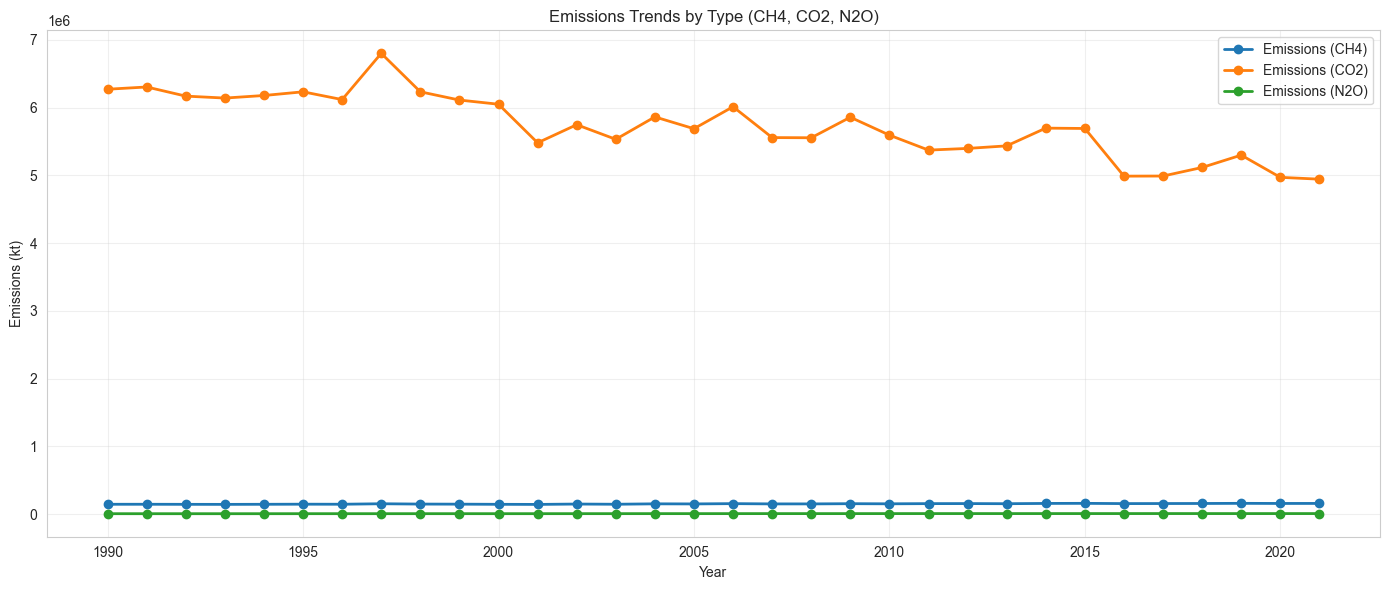

In [17]:
# Emissions trend by element type
element_trend = df.groupby(['Year', 'Element'])['Value'].sum().reset_index()

plt.figure(figsize=(14, 6))
for element in element_trend['Element'].unique():
    data = element_trend[element_trend['Element'] == element]
    plt.plot(data['Year'], data['Value'], marker='o', label=element, linewidth=2)

plt.xlabel('Year')
plt.ylabel('Emissions (kt)')
plt.title('Emissions Trends by Type (CH4, CO2, N2O)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Emissions by Type Over Time

Top 10 Countries by Total Emissions:
Area
Brazil                              4.014199e+07
Indonesia                           2.502947e+07
Democratic Republic of the Congo    1.437344e+07
China                               7.846409e+06
China, mainland                     7.714215e+06
United States of America            5.172587e+06
Canada                              5.152110e+06
India                               4.637062e+06
Myanmar                             3.935015e+06
Argentina                           3.595725e+06
Name: Value, dtype: float64


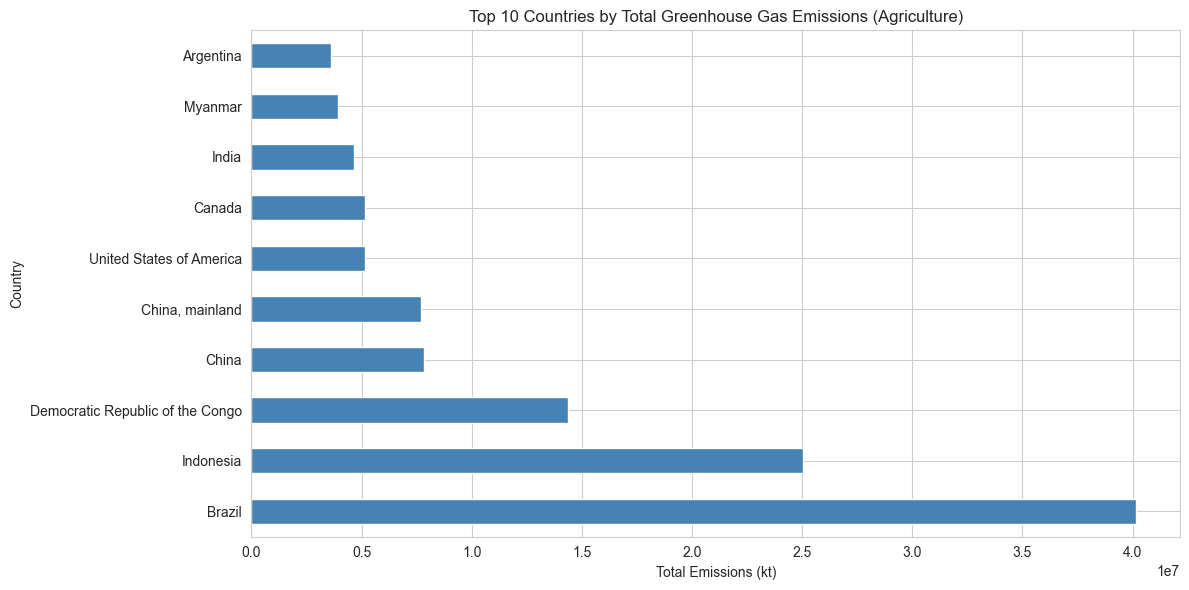

In [13]:
top_countries = df.groupby('Area')['Value'].sum().sort_values(ascending=False).head(10)
print("Top 10 Countries by Total Emissions:")
print(top_countries)

# Visualize
plt.figure(figsize=(12, 6))
top_countries.plot(kind='barh', color='steelblue')
plt.xlabel('Total Emissions (kt)')
plt.ylabel('Country')
plt.title('Top 10 Countries by Total Greenhouse Gas Emissions (Agriculture)')
plt.tight_layout()
plt.show()

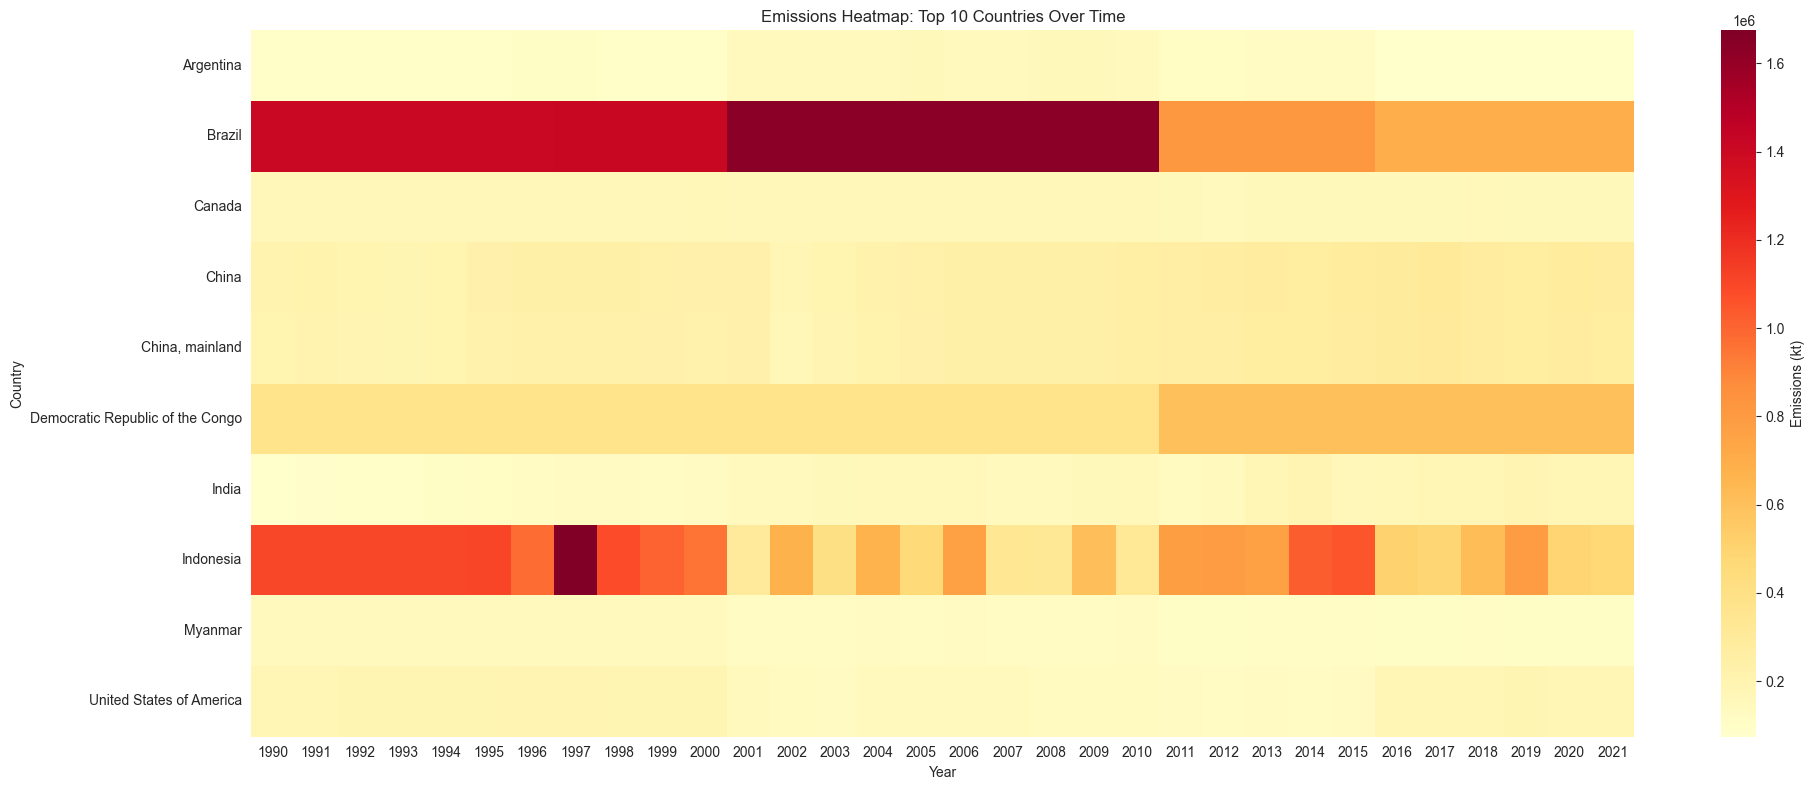

In [18]:
# Heatmap of top countries emissions by year
top_10 = df.groupby('Area')['Value'].sum().sort_values(ascending=False).head(10).index
heatmap_data = df[df['Area'].isin(top_10)].pivot_table(values='Value', index='Area', columns='Year', aggfunc='sum')

plt.figure(figsize=(20, 8))
sns.heatmap(heatmap_data, cmap='YlOrRd', cbar_kws={'label': 'Emissions (kt)'})
plt.title('Emissions Heatmap: Top 10 Countries Over Time')
plt.xlabel('Year')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

## 10. Correlation & Regional Analysis

## 5. Top Countries by Emissions

In [12]:
print("Unique Elements:")
print(df['Element'].unique())
print(f"\nUnique Items:")
print(df['Item'].unique())
print(f"\nYear Range: {df['Year'].min()} - {df['Year'].max()}")
print(f"\nNumber of Countries: {df['Area'].nunique()}")
print(f"\nNumber of Sources: {df['Source'].nunique()}")

Unique Elements:
<StringArray>
['Emissions (CH4)', 'Emissions (CO2)', 'Emissions (N2O)']
Length: 3, dtype: str

Unique Items:
<StringArray>
['Emissions on agricultural land']
Length: 1, dtype: str

Year Range: 1990 - 2021

Number of Countries: 243

Number of Sources: 1


## 4. Unique Items & Elements

In [10]:
print("Statistical Summary:")
print(df.describe())

Statistical Summary:
       Area Code (M49)  Element Code  Item Code     Year Code          Year  \
count     22216.000000  22216.000000    22216.0  22216.000000  22216.000000   
mean        436.902008   7242.692114     6995.0   2005.622344   2005.622344   
std         253.450163     21.551371        0.0      9.183770      9.183770   
min           4.000000   7225.000000     6995.0   1990.000000   1990.000000   
25%         218.000000   7225.000000     6995.0   1998.000000   1998.000000   
50%         434.000000   7230.000000     6995.0   2006.000000   2006.000000   
75%         659.000000   7273.000000     6995.0   2014.000000   2014.000000   
max         894.000000   7273.000000     6995.0   2021.000000   2021.000000   

       Source Code         Value  Note  
count      22216.0  2.221600e+04   0.0  
mean        3050.0  8.487653e+03   NaN  
std            0.0  6.420424e+04   NaN  
min         3050.0  0.000000e+00   NaN  
25%         3050.0  1.946475e+00   NaN  
50%         3050.0  3

## 3. Statistical Summary

In [11]:
print("Data Types:")
print(df.dtypes)
print("\n" + "="*50)
print("Missing Values:")
print(df.isnull().sum())
print("\n" + "="*50)
print("Unique Values per Column:")
for col in df.columns:
    print(f"{col}: {df[col].nunique()}")

Data Types:
Domain Code             str
Domain                  str
Area Code (M49)       int64
Area                    str
Element Code          int64
Element                 str
Item Code             int64
Item                    str
Year Code             int64
Year                  int64
Source Code           int64
Source                  str
Unit                    str
Value               float64
Flag                    str
Flag Description        str
Note                float64
dtype: object

Missing Values:
Domain Code             0
Domain                  0
Area Code (M49)         0
Area                    0
Element Code            0
Element                 0
Item Code               0
Item                    0
Year Code               0
Year                    0
Source Code             0
Source                  0
Unit                    0
Value                   0
Flag                    0
Flag Description        0
Note                22216
dtype: int64

Unique Values per Column:

## 2. Data Info & Structure

In [9]:
# Load the data
df = pd.read_csv('global_greenhouse_gas_emission_from_agriculture (1).csv')
print(f"Dataset shape: {df.shape}")
print(f"\nFirst few rows:")
print(df.head())

Dataset shape: (22216, 17)

First few rows:
  Domain Code            Domain  Area Code (M49)         Area  Element Code  \
0          GT  Emissions totals                4  Afghanistan          7225   
1          GT  Emissions totals                4  Afghanistan          7225   
2          GT  Emissions totals                4  Afghanistan          7225   
3          GT  Emissions totals                4  Afghanistan          7225   
4          GT  Emissions totals                4  Afghanistan          7225   

           Element  Item Code                            Item  Year Code  \
0  Emissions (CH4)       6995  Emissions on agricultural land       1990   
1  Emissions (CH4)       6995  Emissions on agricultural land       1991   
2  Emissions (CH4)       6995  Emissions on agricultural land       1992   
3  Emissions (CH4)       6995  Emissions on agricultural land       1993   
4  Emissions (CH4)       6995  Emissions on agricultural land       1994   

   Year  Source Code    